In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("willianoliveiragibin/mortality-rate-infant-per-1000-live-births")

print("Path to dataset files:", path)

100%|██████████| 18.1k/18.1k [00:00<00:00, 24.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/willianoliveiragibin/mortality-rate-infant-per-1000-live-births/versions/1


In [ ]:
import pandas as pd
import os

os.listdir(path)

['T2.csv', 't3.csv', 'T1.csv']

In [ ]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "T1.csv"), skiprows=1)

df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,United Arab Emirates,ARE,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN,135.5,128.9,122.5,116.2,109.9,103.3,...,7.0,6.8,6.7,6.5,6.3,6.2,6.0,5.8,5.6,5.4
1,Antigua and Barbuda,ATG,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN,62.9,58.8,54.3,49.6,44.9,40.4,...,7.5,7.1,6.8,6.5,6.2,6.0,5.7,5.5,5.3,5.2
2,Australia,AUS,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN,20.3,19.9,19.5,19.1,18.7,18.5,...,3.6,3.5,3.3,3.3,3.2,3.2,3.2,3.2,3.2,3.2
3,Austria,AUT,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN,37.3,34.9,32.9,31.1,29.6,28.3,...,3.3,3.2,3.1,3.0,3.0,2.9,2.9,2.9,3.0,3.0
4,Belgium,BEL,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN,29.4,28.1,27.0,26.0,25.0,24.0,...,3.5,3.4,3.4,3.4,3.3,3.4,3.4,3.4,3.4,3.4


In [ ]:
# rename columns
df = df.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code',
    'Indicator Name': 'indicator',
    'Indicator Code': 'indicator_code'
})

year_cols = [c for c in df.columns if str(c).isdigit()]  # years like '1960'...'2021'
df = df[['country', 'country_code'] + year_cols]

# change to numeric
df[year_cols] = df[year_cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
df.head()

,country,country_code,1960,1961,1962,1963,1964,1965,1966,1967,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,United Arab Emirates,ARE,135.5,128.9,122.5,116.2,109.9,103.3,96.6,89.8,...,7.0,6.8,6.7,6.5,6.3,6.2,6.0,5.8,5.6,5.4
1,Antigua and Barbuda,ATG,62.9,58.8,54.3,49.6,44.9,40.4,36.1,32.3,...,7.5,7.1,6.8,6.5,6.2,6.0,5.7,5.5,5.3,5.2
2,Australia,AUS,20.3,19.9,19.5,19.1,18.7,18.5,18.3,18.2,...,3.6,3.5,3.3,3.3,3.2,3.2,3.2,3.2,3.2,3.2
3,Austria,AUT,37.3,34.9,32.9,31.1,29.6,28.3,27.2,26.3,...,3.3,3.2,3.1,3.0,3.0,2.9,2.9,2.9,3.0,3.0
4,Belgium,BEL,29.4,28.1,27.0,26.0,25.0,24.0,23.2,22.5,...,3.5,3.4,3.4,3.4,3.3,3.4,3.4,3.4,3.4,3.4


In [ ]:
# change to long format
df_long = df.melt(
    id_vars=['country', 'country_code'],
    value_vars=year_cols,
    var_name='year',
    value_name='infant_mortality_rate'
)
df_long['year'] = df_long['year'].astype(int)

In [ ]:
df_long.head()

,country,country_code,year,infant_mortality_rate
0,United Arab Emirates,ARE,1960,135.5
1,Antigua and Barbuda,ATG,1960,62.9
2,Australia,AUS,1960,20.3
3,Austria,AUT,1960,37.3
4,Belgium,BEL,1960,29.4


In [ ]:
t2 = pd.read_csv(os.path.join(path, "T2.csv"))

In [ ]:
t2 = t2.rename(columns={
    'TableName': 'country',
    'IncomeGroup': 'income_group',
    'Region': 'region'
})

In [ ]:
t2.head()

,region,income_group,SpecialNotes,country
0,South Asia,Low income,The reporting period for national accounts dat...,Afghanistan
1,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola
2,Latin America & Caribbean,Upper middle income,The World Bank systematically assesses the app...,Argentina
3,East Asia & Pacific,High income,The reporting period for national accounts dat...,Australia
4,Europe & Central Asia,High income,A simple multiplier is used to convert the nat...,Austria


In [ ]:
t2["country"].unique()

array(['Afghanistan', 'Angola', 'Argentina', 'Australia', 'Austria',
       'Burundi', 'Belgium', 'Bangladesh', 'Belarus', 'Canada', 'China',
       'Congo, Dem. Rep.', 'Cyprus', 'Germany', 'Egypt, Arab Rep.',
       'Eritrea', 'Spain', 'Estonia', 'Ethiopia', 'Finland', 'France',
       'Micronesia, Fed. Sts.', 'Georgia', 'Ghana', 'Gibraltar', 'Greece',
       'Guatemala', 'Hong Kong SAR, China', 'Honduras', 'Croatia',
       'Haiti', 'Indonesia', 'Isle of Man', 'India', 'Ireland',
       'Iran, Islamic Rep.', 'Italy', 'Japan', 'Kenya', 'Cambodia',
       'Lao PDR', 'Lebanon', 'Liberia', 'Lesotho', 'Lithuania',
       'Luxembourg', 'Latvia', 'Macao SAR, China', 'Moldova',
       'Marshall Islands', 'Malta', 'Myanmar', 'Montenegro', 'Mongolia',
       'Mauritania', 'Namibia', 'Nigeria', 'Nicaragua', 'Netherlands',
       'Nepal', 'Nauru', 'New Zealand', 'Pakistan', 'Peru', 'Palau',
       'Puerto Rico', 'Portugal', 'Paraguay', 'West Bank and Gaza',
       'Romania', 'Sudan', 'Singapore'

In [ ]:
df_long = df_long.merge(
    t2[["region", "country", "income_group"]],
    on="country",
    how="left")

In [ ]:
df_long.head()

,country,country_code,year,infant_mortality_rate,region,income_group
0,United Arab Emirates,ARE,1960,135.5,NaN,NaN
1,Antigua and Barbuda,ATG,1960,62.9,NaN,NaN
2,Australia,AUS,1960,20.3,East Asia & Pacific,High income
3,Austria,AUT,1960,37.3,Europe & Central Asia,High income
4,Belgium,BEL,1960,29.4,Europe & Central Asia,High income


In [ ]:
df_long.size

43524

In [ ]:
len(df_long)

7254

In [ ]:
len(df_long.columns.unique())

6

In [ ]:
df_long.isna().sum()

,0
country,0
country_code,0
year,0
infant_mortality_rate,0
region,4340
income_group,4340


In [ ]:
df_long["region"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7254 entries, 0 to 7253
Series name: region
Non-Null Count  Dtype 
--------------  ----- 
2914 non-null   object
dtypes: object(1)
memory usage: 56.8+ KB


In [ ]:
country_stats = (
    df_long
    .groupby('country')['infant_mortality_rate']
    .agg(['mean', 'median', 'std', 'min', 'max'])
)

country_stats.head()

,mean,median,std,min,max
country,,,,,
Algeria,70.946774,43.35,49.873459,19.2,147.7
Antigua and Barbuda,16.659677,11.95,13.351373,5.2,62.9
Australia,9.341935,7.35,5.735754,3.2,20.3
Austria,12.125806,7.80,10.028140,2.9,37.3
Bahrain,30.591935,19.45,31.882851,5.9,133.0


In [ ]:
year_stats = (
    df_long
    .groupby('year')['infant_mortality_rate']
    .agg(['mean', 'median', 'std', 'min', 'max'])
)

year_stats.head()

,mean,median,std,min,max
year,,,,,
1960,98.122222,101.4,53.774106,16.3,220.4
1961,95.184615,95.2,53.096632,16.0,217.3
1962,92.407692,89.0,52.430937,15.6,214.3
1963,89.764957,86.1,51.801017,15.0,211.1
1964,87.294017,83.7,51.161253,14.3,208.1


In [ ]:
df_long.head()

,country,country_code,year,infant_mortality_rate,region,income_group
0,United Arab Emirates,ARE,1960,135.5,NaN,NaN
1,Antigua and Barbuda,ATG,1960,62.9,NaN,NaN
2,Australia,AUS,1960,20.3,East Asia & Pacific,High income
3,Austria,AUT,1960,37.3,Europe & Central Asia,High income
4,Belgium,BEL,1960,29.4,Europe & Central Asia,High income


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
country_means = (
    df_long
    .groupby('country', as_index=False)['infant_mortality_rate']
    .mean()
    .sort_values(by='infant_mortality_rate', ascending=False)
)

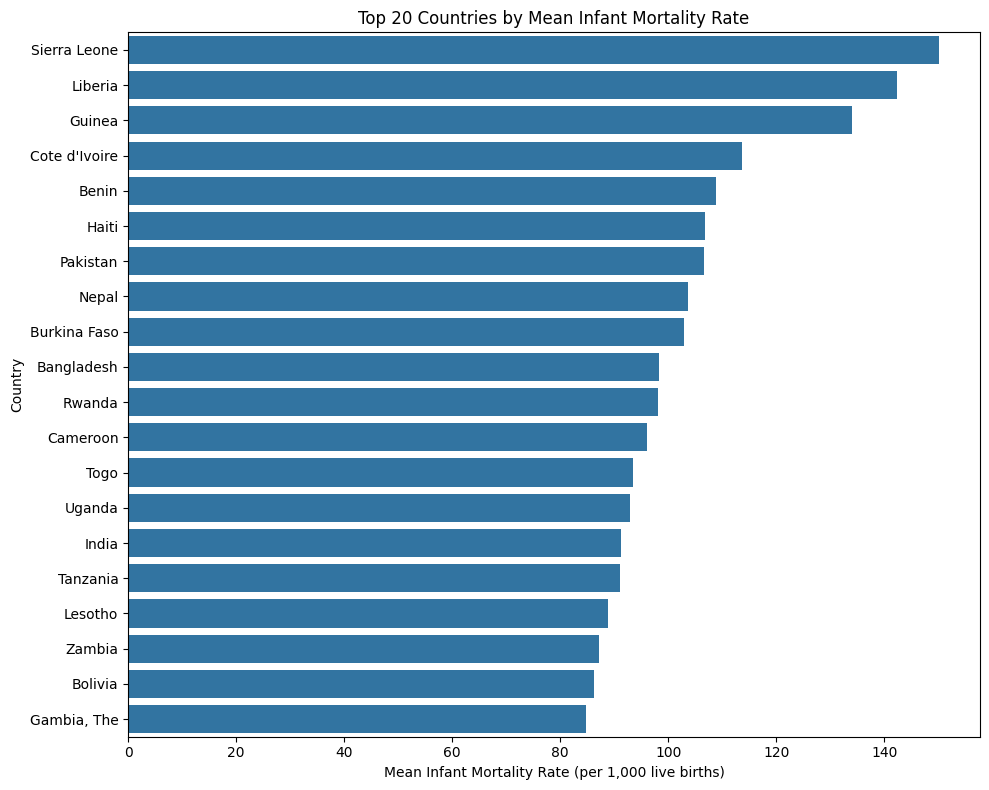

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=country_means.head(20),
    x='infant_mortality_rate',
    y='country'
)

plt.xlabel('Mean Infant Mortality Rate (per 1,000 live births)')
plt.ylabel('Country')
plt.title('Top 20 Countries by Mean Infant Mortality Rate')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

In [ ]:
np.random.seed(42)
random_countries = np.random.choice(
    df_long['country'].unique(),
    size=10,
    replace=False
)

df_subset = df_long[df_long['country'].isin(random_countries)]

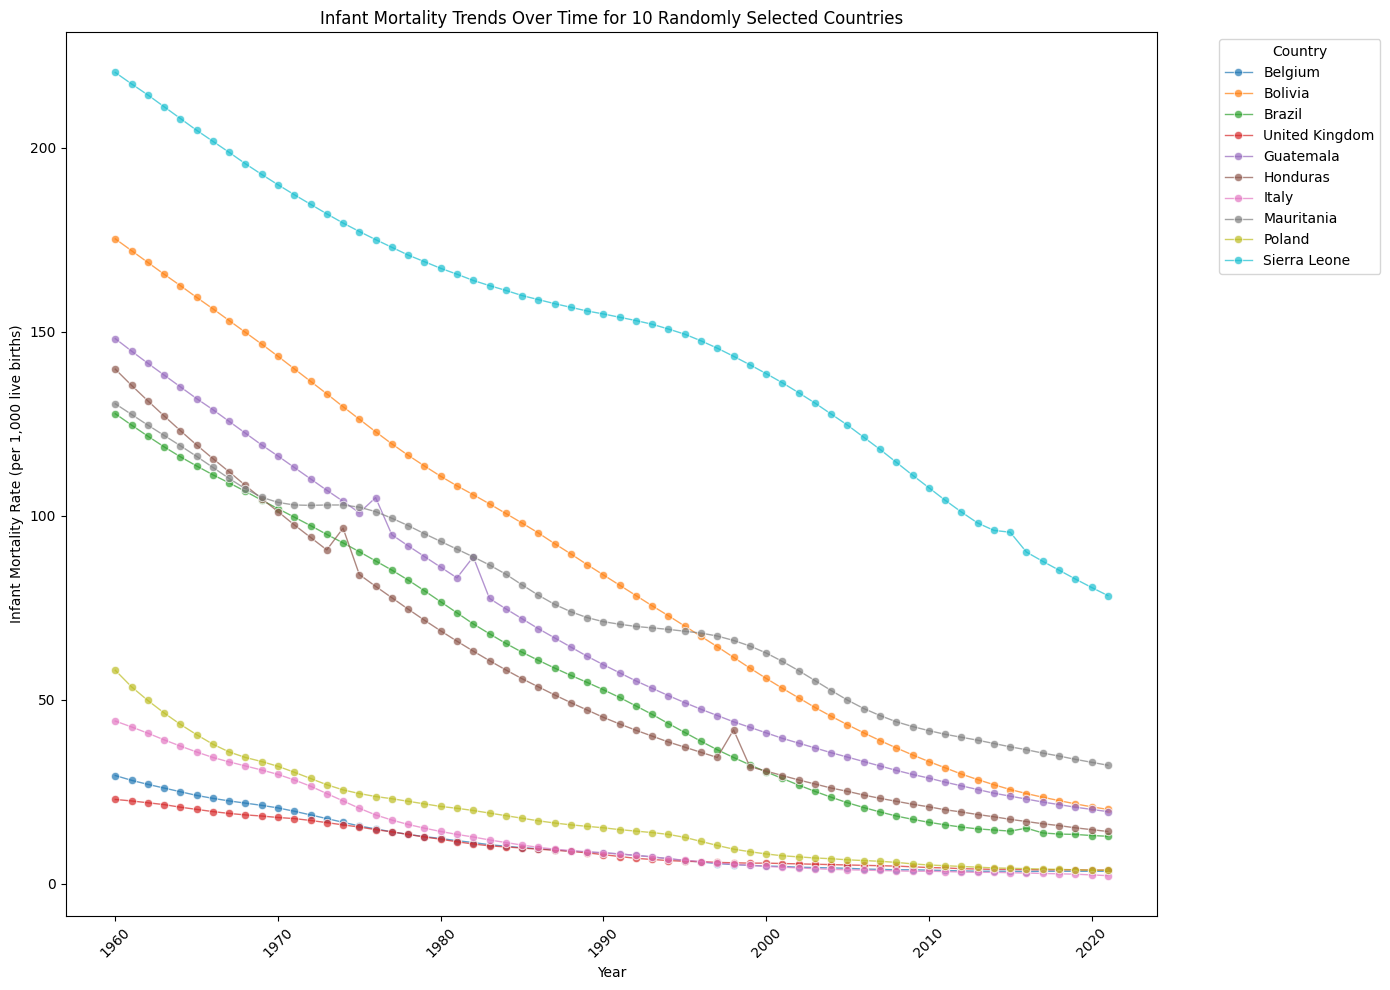

In [ ]:
# decade ticks (e.g. 1960, 1970, ..., 2020)
decades = np.arange(
    df_subset['year'].min(),
    df_subset['year'].max() + 1,
    10
)

plt.figure(figsize=(14, 10))

sns.lineplot(
    data=df_subset,
    x='year',
    y='infant_mortality_rate',
    hue='country',
    marker='o',
    linewidth=1,
    alpha=0.7
)

plt.xlabel('Year')
plt.ylabel('Infant Mortality Rate (per 1,000 live births)')
plt.title('Infant Mortality Trends Over Time for 10 Randomly Selected Countries')

# Set decade ticks
plt.xticks(decades, rotation=45)

plt.legend(
    title='Country',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

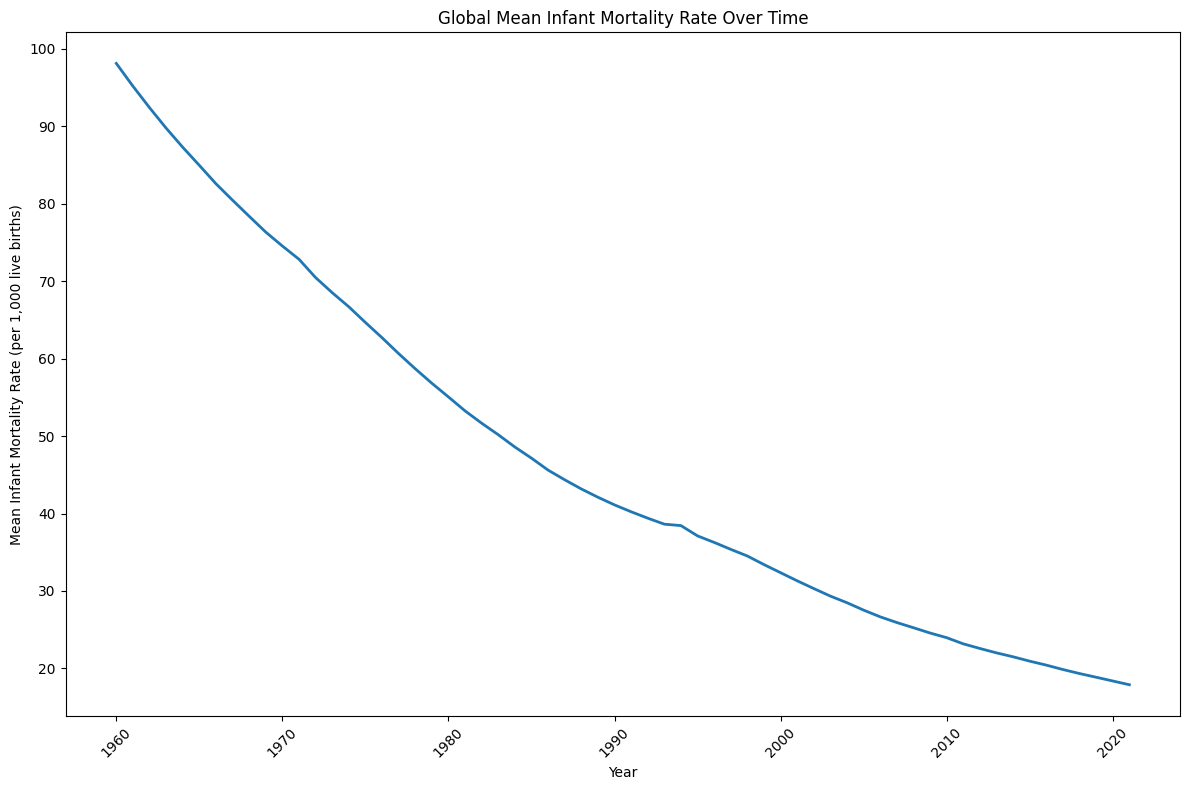

In [ ]:
global_trend = (
    df_long
    .groupby('year', as_index=False)['infant_mortality_rate']
    .mean()
)

plt.figure(figsize=(12, 8))

sns.lineplot(
    data=global_trend,
    x='year',
    y='infant_mortality_rate',
    linewidth=2
)

plt.xlabel('Year')
plt.ylabel('Mean Infant Mortality Rate (per 1,000 live births)')
plt.title('Global Mean Infant Mortality Rate Over Time')

# Decade ticks for cleanliness
decades = np.arange(
    global_trend['year'].min(),
    global_trend['year'].max() + 1,
    10
)
plt.xticks(decades, rotation=45)

plt.tight_layout()
plt.show()

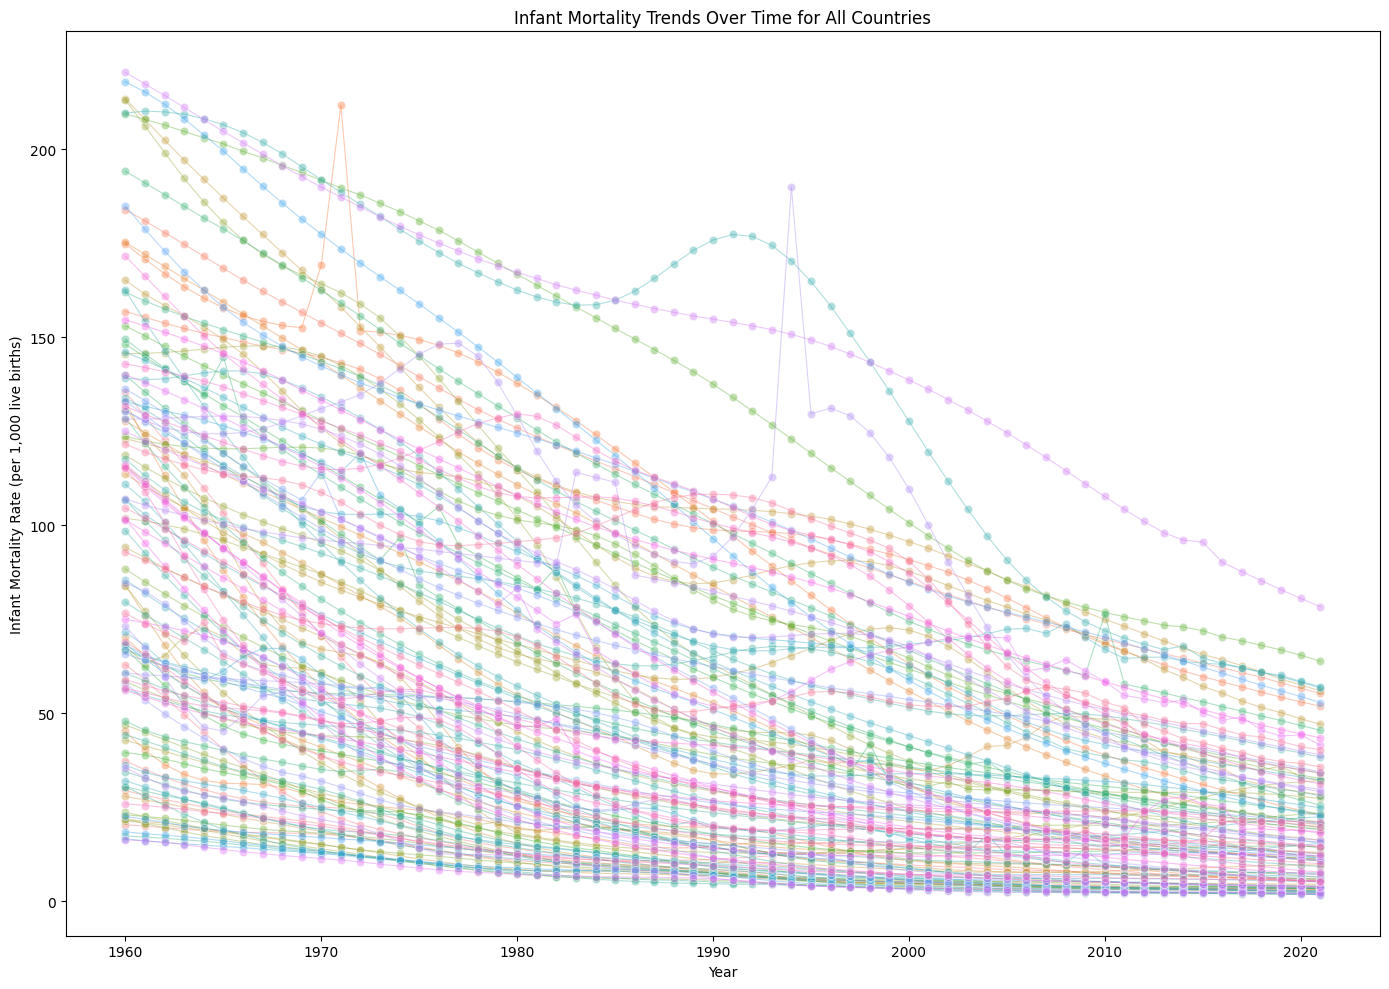

In [ ]:
plt.figure(figsize=(14, 10))

sns.lineplot(
    data=df_long,
    x='year',
    y='infant_mortality_rate',
    hue='country',
    legend=False,      # IMPORTANT: legend would be unusable
    marker='o',
    linewidth=0.8,
    alpha=0.4
)

plt.xlabel('Year')
plt.ylabel('Infant Mortality Rate (per 1,000 live births)')
plt.title('Infant Mortality Trends Over Time for All Countries')

plt.tight_layout()
plt.show()

In [ ]:
region_trends = (
    df_long.dropna(subset=['region'])
    .groupby(['year', 'region'])['infant_mortality_rate']
    .mean()
    .reset_index()
)

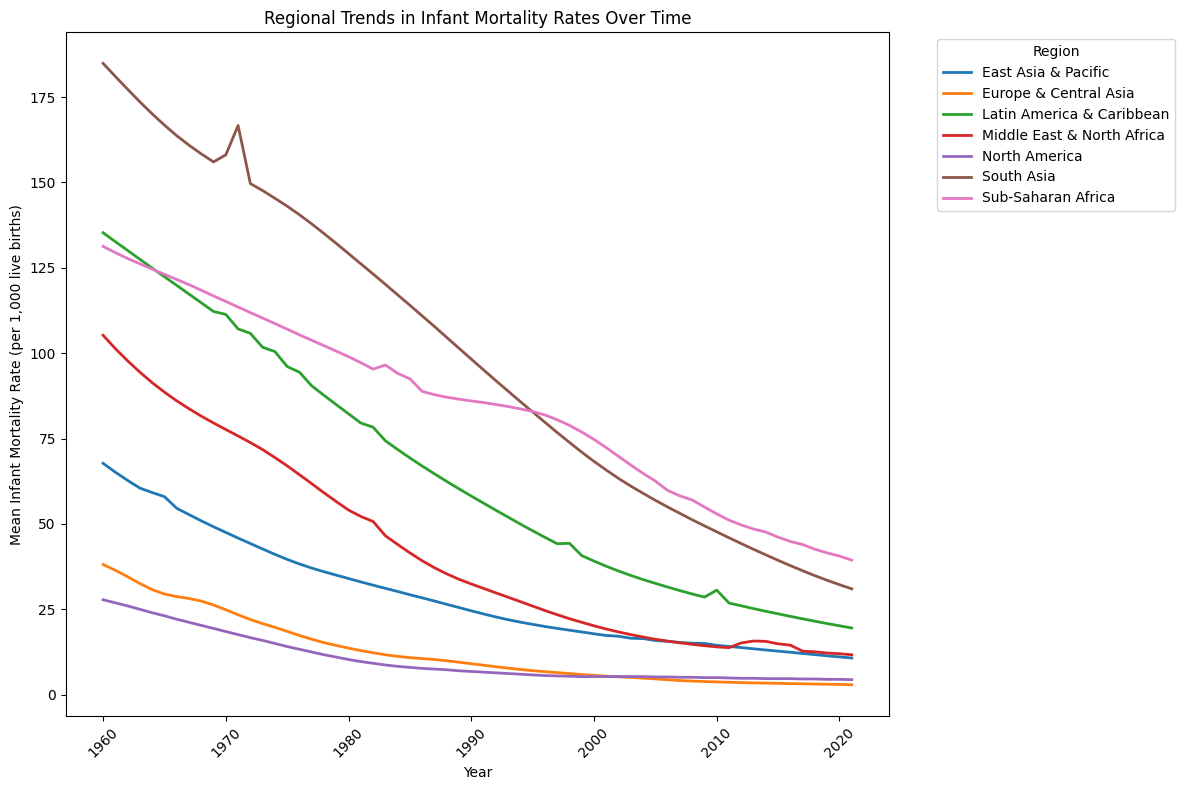

In [ ]:
plt.figure(figsize=(12, 8))

sns.lineplot(
    data=region_trends,
    x='year',
    y='infant_mortality_rate',
    hue='region',
    linewidth=2
)

plt.xlabel('Year')
plt.ylabel('Mean Infant Mortality Rate (per 1,000 live births)')
plt.title('Regional Trends in Infant Mortality Rates Over Time')

# Label decades only (cleaner)
decades = np.arange(region_trends['year'].min(),
                    region_trends['year'].max() + 1,
                    10)
plt.xticks(decades, rotation=45)

plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
income_trends = (
    df_long
    .dropna(subset=['income_group'])
    .groupby(['year', 'income_group'], as_index=False)['infant_mortality_rate']
    .mean()
)

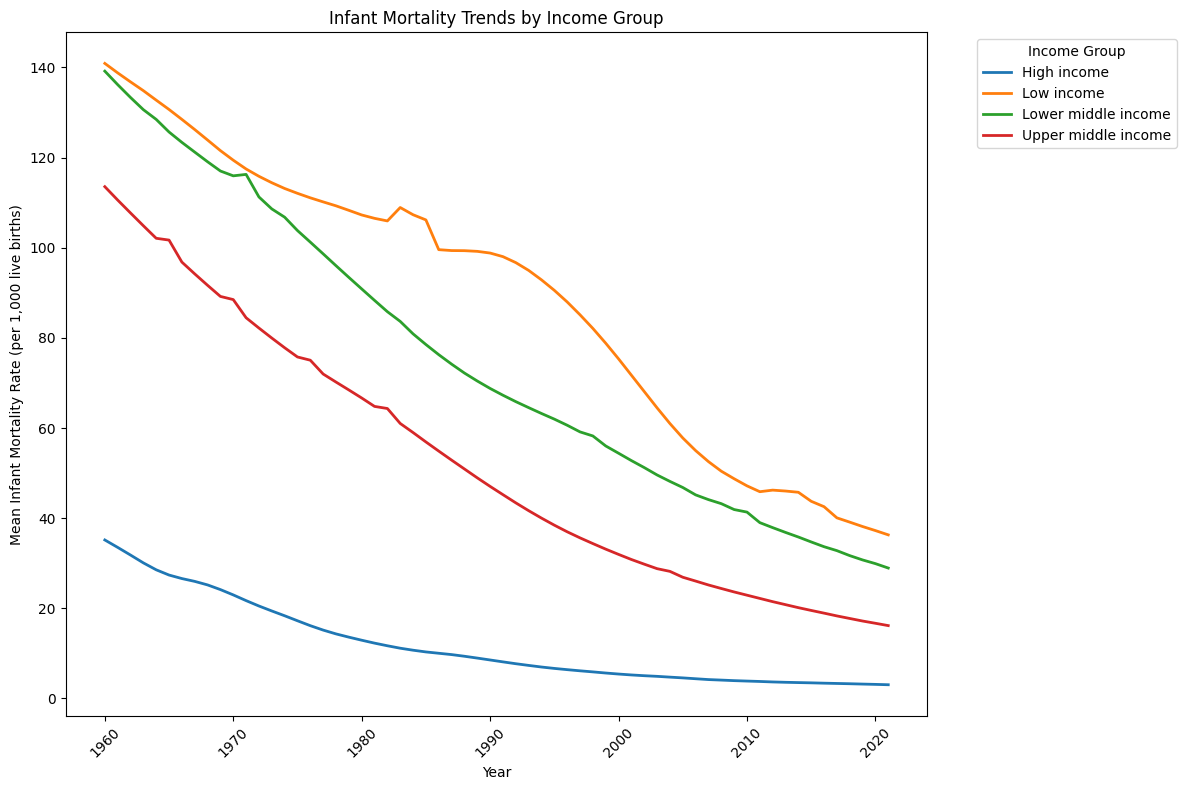

In [ ]:
plt.figure(figsize=(12, 8))

sns.lineplot(
    data=income_trends,
    x='year',
    y='infant_mortality_rate',
    hue='income_group',
    linewidth=2
)

plt.xlabel('Year')
plt.ylabel('Mean Infant Mortality Rate (per 1,000 live births)')
plt.title('Infant Mortality Trends by Income Group')

# Decade labels only
decades = np.arange(
    income_trends['year'].min(),
    income_trends['year'].max() + 1,
    10
)
plt.xticks(decades, rotation=45)

plt.legend(
    title='Income Group',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [ ]:
df_long['decade'] = (df_long['year'] // 10) * 10

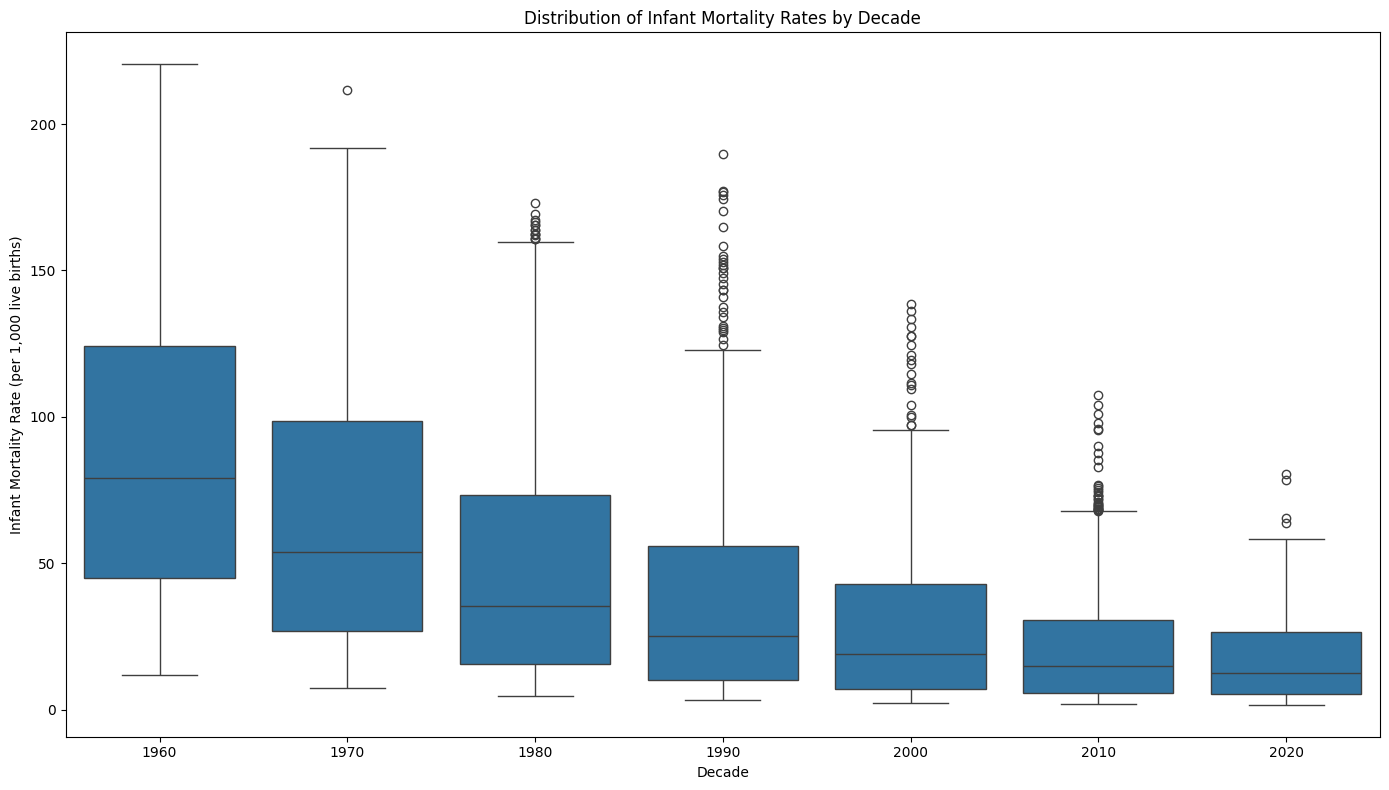

In [ ]:
plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df_long,
    x='decade',
    y='infant_mortality_rate'
)

plt.xlabel('Decade')
plt.ylabel('Infant Mortality Rate (per 1,000 live births)')
plt.title('Distribution of Infant Mortality Rates by Decade')

plt.tight_layout()
plt.show()

In [ ]:
country_features = (
    df_long
    .groupby('country')
    .agg(
        mean_rate=('infant_mortality_rate', 'mean'),
        median_rate=('infant_mortality_rate', 'median'),
        std_rate=('infant_mortality_rate', 'std'),
        min_rate=('infant_mortality_rate', 'min'),
        max_rate=('infant_mortality_rate', 'max')
    )
    .dropna()
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_features)


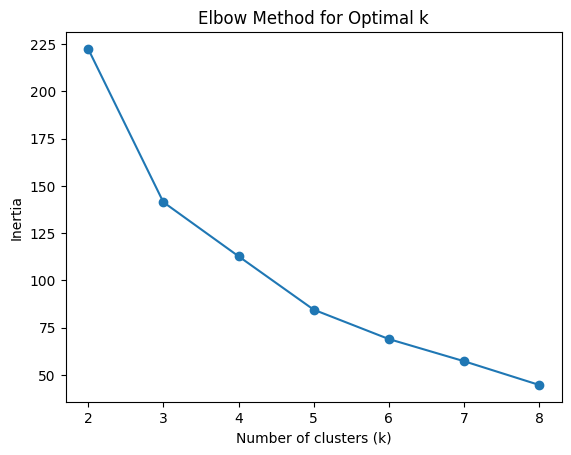

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

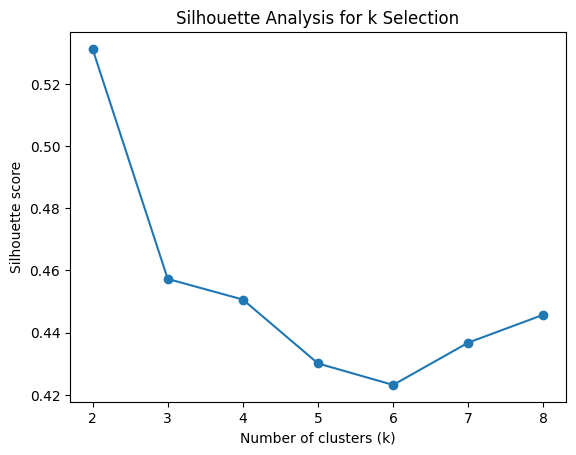

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 9), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Analysis for k Selection')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
country_features['cluster'] = kmeans.fit_predict(X_scaled)


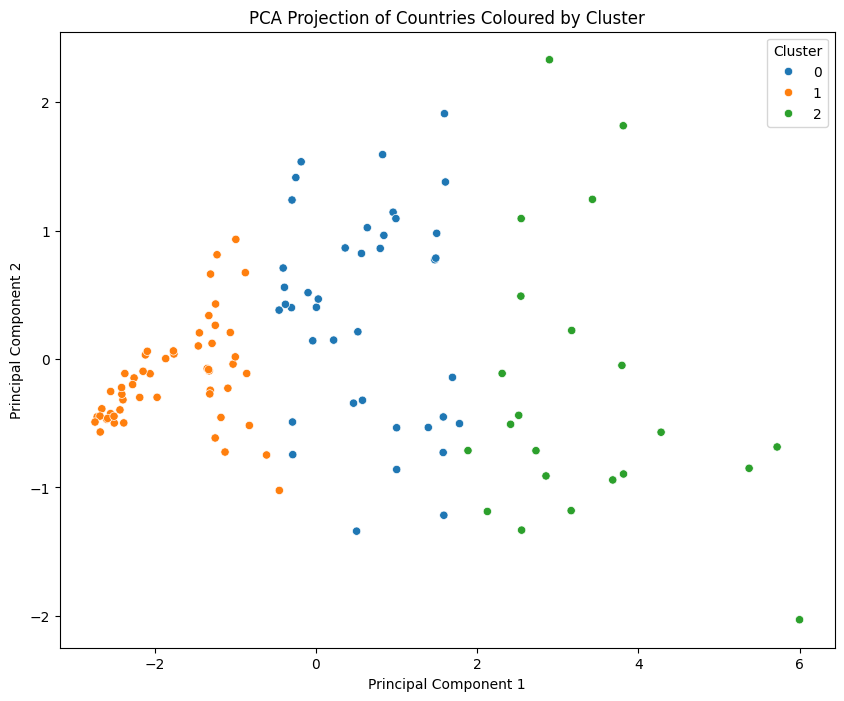

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Build plotting DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=country_features.index
)

pca_df['cluster'] = country_features['cluster'].values

# Plot
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10'
)

plt.title('PCA Projection of Countries Coloured by Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')